# Credit Risk Behavior Analysis

## Objective
The objective of this analysis is to understand whether borrower risk is better explained by:

- Financial strength (income, debt-to-income, installment)
- Historical risk behavior (delinquencies, failed payments, bankruptcies)
- Loan pricing signals (interest rate and grade)

A key question explored is whether interest rate can serve as an indicator of risky borrower behavior, or whether risk is already embedded in the lender's credit grading system.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import math
import seaborn as sns
sns.set_style("darkgrid")   

# Import Data

In [2]:
df=pd.read_csv("loans_full_schema.csv")

In [3]:
pd.set_option('display.max_columns', None)
df.head()


,Unnamed: 0,emp_title,emp_length,state,homeownership,annual_income,verified_income,debt_to_income,annual_income_joint,verification_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_purpose,application_type,loan_amount,term,interest_rate,installment,grade,sub_grade,issue_month,loan_status,initial_listing_status,disbursement_method,balance,paid_total,paid_principal,paid_interest,paid_late_fees
0,1,global config engineer,3.0,NJ,MORTGAGE,90000.0,Verified,18.01,NaN,NaN,NaN,0,38.0,2001,6,28,10,70795,38767,0,0,38.0,0,1250,2,5,5.0,10,0.0,0,2,11100,14,8,6,1,92.9,0,0,moving,individual,28000,60,14.07,652.53,C,C3,Mar-2018,Current,whole,Cash,27015.86,1999.33,984.14,1015.19,0.0
1,2,warehouse office clerk,10.0,HI,RENT,40000.0,Not Verified,5.04,NaN,NaN,NaN,0,NaN,1996,1,30,14,28800,4321,0,1,NaN,0,0,0,11,8.0,14,0.0,0,3,16500,24,14,4,0,100.0,0,1,debt_consolidation,individual,5000,36,12.61,167.54,C,C1,Feb-2018,Current,whole,Cash,4651.37,499.12,348.63,150.49,0.0
2,3,assembly,3.0,WI,RENT,40000.0,Source Verified,21.15,NaN,NaN,NaN,0,28.0,2006,4,31,10,24193,16000,0,0,28.0,0,432,1,13,7.0,10,0.0,0,3,4300,14,8,6,0,93.5,0,0,other,individual,2000,36,17.09,71.40,D,D1,Feb-2018,Current,fractional,Cash,1824.63,281.80,175.37,106.43,0.0
3,4,customer service,1.0,PA,RENT,30000.0,Not Verified,10.16,NaN,NaN,NaN,0,NaN,2007,0,4,4,25400,4997,0,1,NaN,0,0,1,1,15.0,4,0.0,0,2,19400,3,3,2,0,100.0,1,0,debt_consolidation,individual,21600,36,6.72,664.19,A,A3,Jan-2018,Current,whole,Cash,18853.26,3312.89,2746.74,566.15,0.0
4,5,security supervisor,10.0,CA,RENT,35000.0,Verified,57.96,57000.0,Verified,37.66,0,NaN,2008,7,22,16,69839,52722,0,0,NaN,0,0,1,6,4.0,16,0.0,0,10,32700,20,15,13,0,100.0,0,0,credit_card,joint,23000,36,14.07,786.87,C,C3,Mar-2018,Current,whole,Cash,21430.15,2324.65,1569.85,754.80,0.0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,Unnamed: 0,emp_length,annual_income,debt_to_income,annual_income_joint,debt_to_income_joint,delinq_2y,months_since_last_delinq,earliest_credit_line,inquiries_last_12m,total_credit_lines,open_credit_lines,total_credit_limit,total_credit_utilized,num_collections_last_12m,num_historical_failed_to_pay,months_since_90d_late,current_accounts_delinq,total_collection_amount_ever,current_installment_accounts,accounts_opened_24m,months_since_last_credit_inquiry,num_satisfactory_accounts,num_accounts_120d_past_due,num_accounts_30d_past_due,num_active_debit_accounts,total_debit_limit,num_total_cc_accounts,num_open_cc_accounts,num_cc_carrying_balance,num_mort_accounts,account_never_delinq_percent,tax_liens,public_record_bankrupt,loan_amount,term,interest_rate,installment,balance,paid_total,paid_principal,paid_interest,paid_late_fees
count,10000.00000,9183.000000,1.000000e+04,9976.000000,1.495000e+03,1495.000000,10000.00000,4342.000000,10000.00000,10000.00000,10000.000000,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,2285.000000,10000.0000,10000.000000,10000.000000,10000.000000,8729.000000,10000.000000,9682.0,10000.0000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,5.930306,7.922215e+04,19.308192,1.279146e+05,19.979304,0.21600,36.760709,2001.29000,1.95820,22.679600,11.40440,1.836062e+05,51049.063100,0.013800,0.167100,46.112473,0.0001,184.334000,2.663600,4.376100,7.340703,11.379600,0.0,0.0001,3.595300,27357.410300,13.030000,8.095000,5.230500,1.383100,94.648990,0.043300,0.123800,16361.922500,43.272000,12.427524,476.205323,14458.916610,2494.234773,1894.448466,599.666781,0.119516
std,2886.89568,3.703734,6.473429e+04,15.004851,7.016838e+04,8.054781,0.68366,21.634939,7.79551,2.38013,11.885439,5.86828,1.876327e+05,53636.731172,0.126535,0.687768,21.748021,0.0100,2206.389859,2.935387,3.158583,5.981590,5.859705,0.0,0.0100,2.434689,26570.164081,7.874713,4.906606,3.327623,1.717274,9.155059,0.593852,0.337172,10301.956759,11.029877,5.001105,294.851627,9964.561865,3958.230365,3884.407175,517.328062,1.813468
min,1.00000,0.000000,0.000000e+00,0.000000,1.920000e+04,0.320000,0.00000,1.000000,1963.00000,0.00000,2.000000,0.00000,0.000000e+00,0.000000,0.000000,0.000000,2.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,14.300000,0.000000,0.000000,1000.000000,36.000000,5.310000,30.750000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2500.75000,2.000000,4.500000e+04,11.057500,8.683350e+04,14.160000,0.00000,19.000000,1997.00000,0.00000,14.000000,7.00000,5.159375e+04,19185.500000,0.000000,0.000000,29.000000,0.0000,0.000000,1.000000,2.000000,2.000000,7.000000,0.0,0.0000,2.000000,10000.000000,7.000000,5.000000,3.000000,0.000000,92.600000,0.000000,0.000000,8000.000000,36.000000,9.430000,256.040000,6679.065000,928.700000,587.100000,221.757500,0.000000
50%,5000.50000,6.000000,6.500000e+04,17.570000,1.130000e+05,19.720000,0.00000,34.000000,2003.00000,1.00000,21.000000,10.00000,1.146670e+05,36927.000000,0.000000,0.000000,47.000000,0.0000,0.000000,2.000000,4.000000,6.000000,10.000000,0.0,0.0000,3.000000,19500.000000,11.000000,7.000000,5.000000,1.000000,100.000000,0.000000,0.000000,14500.000000,36.000000,11.980000,398.420000,12379.495000,1563.300000,984.990000,446.140000,0.000000
75%,7500.25000,10.000000,9.500000e+04,25.002500,1.515455e+05,25.500000,0.00000,53.000000,2006.00000,3.00000,29.000000,14.00000,2.675500e+05,65421.000000,0.000000,0.000000,63.000000,0.0000,0.000000,3.000000,6.000000,11.000000,14.000000,0.0,0.0000,5.000000,36100.000000,17.000000,10.000000,7.000000,2.000000,100.000000,0.000000,0.000000,24000.000000,60.000000,15.050000,644.690000,20690.182500,2616.005000,1694.555000,825.420000,0.000000
max,10000.00000,10.000000,2.300000e+06,469.090000,1.100000e+06,39.980000,

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        10000 non-null  int64  
 1   emp_title                         9167 non-null   object 
 2   emp_length                        9183 non-null   float64
 3   state                             10000 non-null  object 
 4   homeownership                     10000 non-null  object 
 5   annual_income                     10000 non-null  float64
 6   verified_income                   10000 non-null  object 
 7   debt_to_income                    9976 non-null   float64
 8   annual_income_joint               1495 non-null   float64
 9   verification_income_joint         1455 non-null   object 
 10  debt_to_income_joint              1495 non-null   float64
 11  delinq_2y                         10000 non-null  int64  
 12  month

In [7]:
df.isnull().sum()

Unnamed: 0                             0
emp_title                            833
emp_length                           817
state                                  0
homeownership                          0
annual_income                          0
verified_income                        0
debt_to_income                        24
annual_income_joint                 8505
verification_income_joint           8545
debt_to_income_joint                8505
delinq_2y                              0
months_since_last_delinq            5658
earliest_credit_line                   0
inquiries_last_12m                     0
total_credit_lines                     0
open_credit_lines                      0
total_credit_limit                     0
total_credit_utilized                  0
num_collections_last_12m               0
num_historical_failed_to_pay           0
months_since_90d_late               7715
current_accounts_delinq                0
total_collection_amount_ever           0
current_installm

No duplicate data

We will first analyse the raw data without handling missing data 

Styling

In [8]:
primary = "#1f77b4"   # muted blue
highlight = "#d62728" # red (only for emphasis)
neutral = "#9e9e9e"   # grey
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")
plt.rcParams.update({
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8
})


## Understanding the borrower population

Before analyzing risk, we first examine the distribution of borrower financial strength, credit history, and loan characteristics to understand the composition of the dataset.

# Univariate Data Analysis

In [9]:
df.columns

Index(['Unnamed: 0', 'emp_title', 'emp_length', 'state', 'homeownership',
       'annual_income', 'verified_income', 'debt_to_income',
       'annual_income_joint', 'verification_income_joint',
       'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq',
       'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines',
       'open_credit_lines', 'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'publi

Borrower Financial Strength (Ability to Pay)

1) annual_income/annual_income_joint(annual income joint is insignificant in numbers so there is no point analysing its distribution but we analyse borrowers behaviour for joint annual income same goes with other feautures dealing with joint account )(done)
2) verified_income / verification_income_joint(done)
3) debt_to_income / debt_to_income_joint(done)
4) installment(done)
   
Credit History & Past Behavior

6) delinq_2y
7) months_since_last_delinq
8) months_since_90d_late
9) num_accounts_120d_past_due
10) num_historical_failed_to_pay
11) public_record_bankrupt
    
Credit Utilization & Exposure (Financial Pressure)

13) total_credit_limit
14) total_credit_utilized
15) credit_utilization ratio
    
Credit Activity & Inquiry Behavior

17) inquiries_last_12m
18) months_since_last_credit_inquiry
19) earliest_credit_line
    
 Loan Characteristics (Loan Risk Itself)

21) interest_rate ⭐
22) installment
23) grade / sub_grade
    “Since joint application features like annual_income_joint have a high proportion of missing values, analyzing their distribution on the full dataset is not meaningful. However, they are highly relevant for joint applicants, so I analyze them separately by segmenting the data using application_type.”

In [10]:
df.groupby('emp_length',dropna=False)['loan_status'].value_counts(normalize=True).unstack()

loan_status,Charged Off,Current,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
emp_length,,,,,,
0.0,NaN,0.928986,0.053623,0.002899,0.007246,0.007246
1.0,0.001460,0.921168,0.058394,0.007299,0.002920,0.008759
2.0,NaN,0.938987,0.035160,0.012410,0.007239,0.006205
3.0,NaN,0.945476,0.040603,0.001160,0.004640,0.008121
4.0,0.001637,0.936170,0.050736,0.006547,0.003273,0.001637
5.0,0.001550,0.951938,0.032558,0.006202,0.001550,0.006202
6.0,NaN,0.950495,0.044554,NaN,0.002475,0.002475
7.0,0.002717,0.921196,0.057065,0.008152,0.002717,0.008152
8.0,NaN,0.931596,0.039088,0.013029,NaN,0.016287


<Axes: xlabel='emp_length', ylabel='count'>

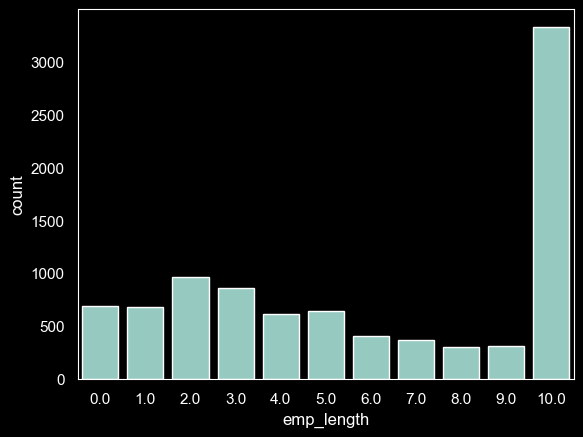

In [11]:
plt.style.use('dark_background')
sns.countplot(data=df,x='emp_length')


Here we can see that most of the employees taking loan and currently have loans is employed for 10 year that means that more stable job will be more chances of taking loans.

### Why analyze annual income?

Income represents borrower repayment capacity.
If financial strength explains risk, lower-income borrowers should exhibit riskier behavior.

1) Annual Income

In [12]:
df['annual_income'].describe()

count    1.000000e+04
mean     7.922215e+04
std      6.473429e+04
min      0.000000e+00
25%      4.500000e+04
50%      6.500000e+04
75%      9.500000e+04
max      2.300000e+06
Name: annual_income, dtype: float64

Here we can see that mean and median is around 79000 and 65000 respectively and max vis around 2300000 which clearly indicates that data is highly skewed toward higher value(right skewed)

(9.0, 16.0)

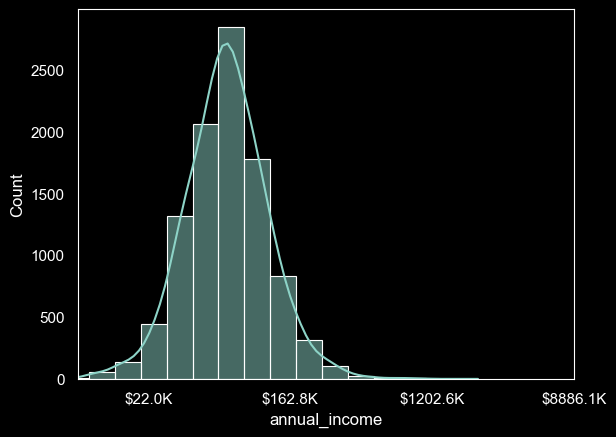

In [13]:
ax=sns.histplot(x=np.log1p(df['annual_income']),kde=True,bins=40)
ticks = ax.get_xticks()
labels = [f"${np.expm1(t)/1e3:.1f}K" for t in ticks]
ax.set_xticks(ticks)
ax.set_xticklabels(labels)
plt.xlim(9, None)

“The distribution of annual income shows a strong concentration of loan applicants in the mid-income range ($20K–$160K), with relatively fewer individuals in both lower and higher income brackets. This suggests that lending activity is primarily concentrated among individuals with moderate income levels. While the mid-income group presents a key opportunity for targeted marketing strategies, the limited representation of extreme income groups may reflect either dataset bias or differing financial behaviors, which require further investigation.

In [14]:
#Analysing wheather verification and non verification has effect on risk behaviour

In [15]:
df.groupby('verified_income',dropna=False)['loan_status'].value_counts(normalize=True).unstack()*100

loan_status,Charged Off,Current,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
verified_income,,,,,,
Not Verified,0.083472,94.602115,4.229271,0.556483,0.111297,0.417362
Source Verified,0.048591,93.658892,4.446064,0.704568,0.534500,0.607386
Verified,0.087336,92.576419,4.890830,0.786026,0.524017,1.135371


In [16]:
df['verified_income'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: verified_income
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  object
dtypes: object(1)
memory usage: 78.3+ KB


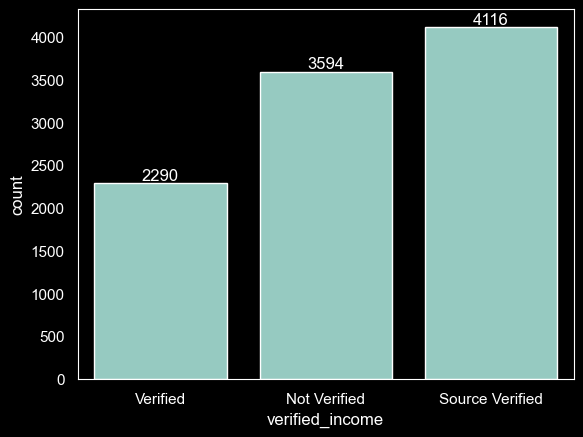

In [17]:
ax=sns.countplot(data=df,x='verified_income')
for container in ax.containers:
    ax.bar_label(container)

“Around 64% of borrowers have verified or source-verified income, while 36% remain unverified. Since income verification plays a crucial role in assessing borrower credibility, we will further analyze how verification status influences borrower behavior, default risk, and repayment performance.”

### Why analyze Debt to Income Ratio?

Debt to Income Ratio represents borrower repayment capacity.
If financial strength explains risk, lower-income borrowers should exhibit riskier behavior.

In [18]:
df['debt_to_income'].describe()

count    9976.000000
mean       19.308192
std        15.004851
min         0.000000
25%        11.057500
50%        17.570000
75%        25.002500
max       469.090000
Name: debt_to_income, dtype: float64

(-23.4545, 200.0)

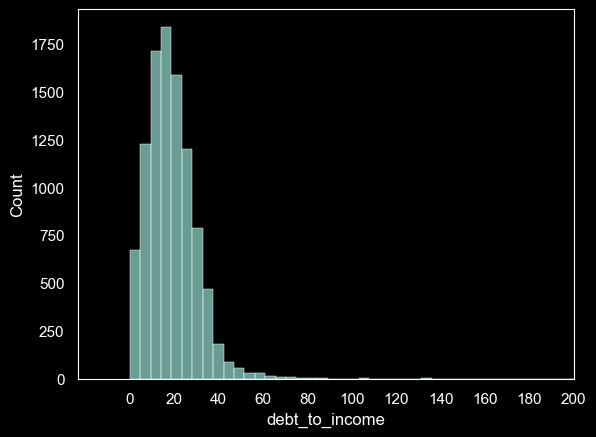

In [19]:
sns.histplot(data=df,x='debt_to_income' ,bins=100)
plt.xticks([0, 20,40,60,80,100,120,140,160,180,200])
plt.xlim(None,200)

""The debt-to-income ratio is highly right-skewed, with the majority of borrowers clustered between 10 and 30. However, a small number of extreme values  with maximum value of $469 indicate borrowers with very high debt burdens, which may significantly increase default risk. This suggests the need for outlier handling or risk-based segmentation."

### Why analyze installment?

Installment captures monthly repayment burden and may provide insight into potential financial stress and risk.

In [20]:
df['installment'].describe()

count    10000.000000
mean       476.205323
std        294.851627
min         30.750000
25%        256.040000
50%        398.420000
75%        644.690000
max       1566.590000
Name: installment, dtype: float64

<Axes: xlabel='installment', ylabel='Count'>

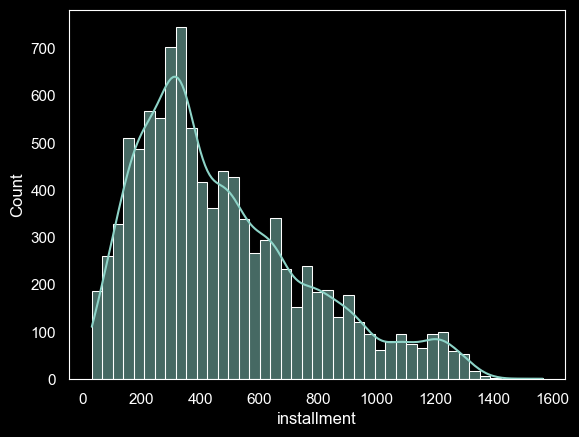

In [21]:
sns.histplot(data=df,x='installment',kde=True)

The distribution of installment amounts is positively skewed, with the majority of borrowers paying monthly installments in the range of 200  to 600, and a peak around " 300– 400". A long right tail is observed, indicating the presence of a smaller group of borrowers with significantly higher installment amounts, reaching up to approximately 1500.

This suggests that most loans are structured with moderate repayment burdens, while a few loans involve substantially higher financial commitments.

In the subsequent analysis, we will examine how installment amounts relate to key variables such as annual income, debt-to-equity ratio, interest rate, grade, and loan amount. Additionally, we will explore whether higher installment amounts are associated with increased risk by comparing them across different loan statuses. Special attention will be given to high-installment outliers to understand whether they are driven by higher loan amounts, higher interest rates, or borrower financial capacity.(All currency in $)

### Why analyze loan status?

Loan status provides the observed repayment outcome of borrowers and helps assess whether borrower characteristics align with repayment performance or delinquency risk.

In [22]:
df['loan_status'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: loan_status
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  object
dtypes: object(1)
memory usage: 78.3+ KB


In [23]:
df['loan_status'].unique()

array(['Current', 'Fully Paid', 'In Grace Period', 'Late (31-120 days)',
       'Charged Off', 'Late (16-30 days)'], dtype=object)

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Current'),
  Text(1, 0, 'Fully Paid'),
  Text(2, 0, 'In Grace Period'),
  Text(3, 0, 'Late (31-120 days)'),
  Text(4, 0, 'Charged Off'),
  Text(5, 0, 'Late (16-30 days)')])

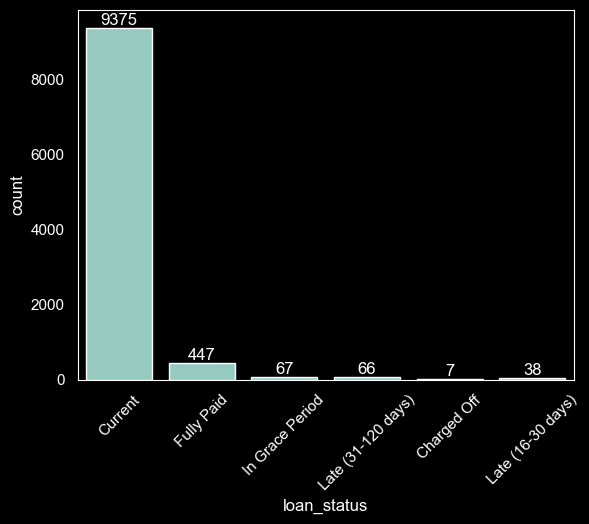

In [24]:
ax=sns.countplot(data=df,x='loan_status')
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45)

The dataset is highly skewed towards “Current” loans, with very few observations in default-related categories. This class imbalance limits the ability to draw strong and reliable conclusions regarding default behavior.

To address this, the analysis will focus on non-current loans by filtering out observations with a “Current” loan status. This allows for a more meaningful comparison between completed and delinquent loans, enabling the identification of potential risk patterns.

While the reduced dataset may still have limitations due to the small number of default cases, it can provide indicative insights into borrower behavior and risk characteristics.


“Most loans are issued between 5% and 15%, with a right-skewed distribution. Higher interest rates may indicate higher-risk borrowers, which we will further validate by comparing with grade, debt-to-equity, and credit utilization.”

## Credit History & Past Behavior

Past repayment behavior is often a stronger indicator of borrower risk than financial capacity alone.  
This section analyzes delinquency, failed payments, and bankruptcy-related variables to assess historical risk behavior.

In [25]:

cols = ['delinq_2y','months_since_last_delinq','months_since_90d_late','num_accounts_120d_past_due','num_historical_failed_to_pay','public_record_bankrupt']

desc = df[cols].describe().T

desc['non_null'] = df[cols].notnull().sum()
desc['missing'] = df[cols].isnull().sum()
desc['dtype'] = df[cols].dtypes


df_summary = desc
df_summary

,count,mean,std,min,25%,50%,75%,max,non_null,missing,dtype
delinq_2y,10000.0,0.216000,0.683660,0.0,0.0,0.0,0.0,13.0,10000,0,int64
months_since_last_delinq,4342.0,36.760709,21.634939,1.0,19.0,34.0,53.0,118.0,4342,5658,float64
months_since_90d_late,2285.0,46.112473,21.748021,2.0,29.0,47.0,63.0,128.0,2285,7715,float64
num_accounts_120d_past_due,9682.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,9682,318,float64
num_historical_failed_to_pay,10000.0,0.167100,0.687768,0.0,0.0,0.0,0.0,52.0,10000,0,int64
public_record_bankrupt,10000.0,0.123800,0.337172,0.0,0.0,0.0,0.0,3.0,10000,0,int64


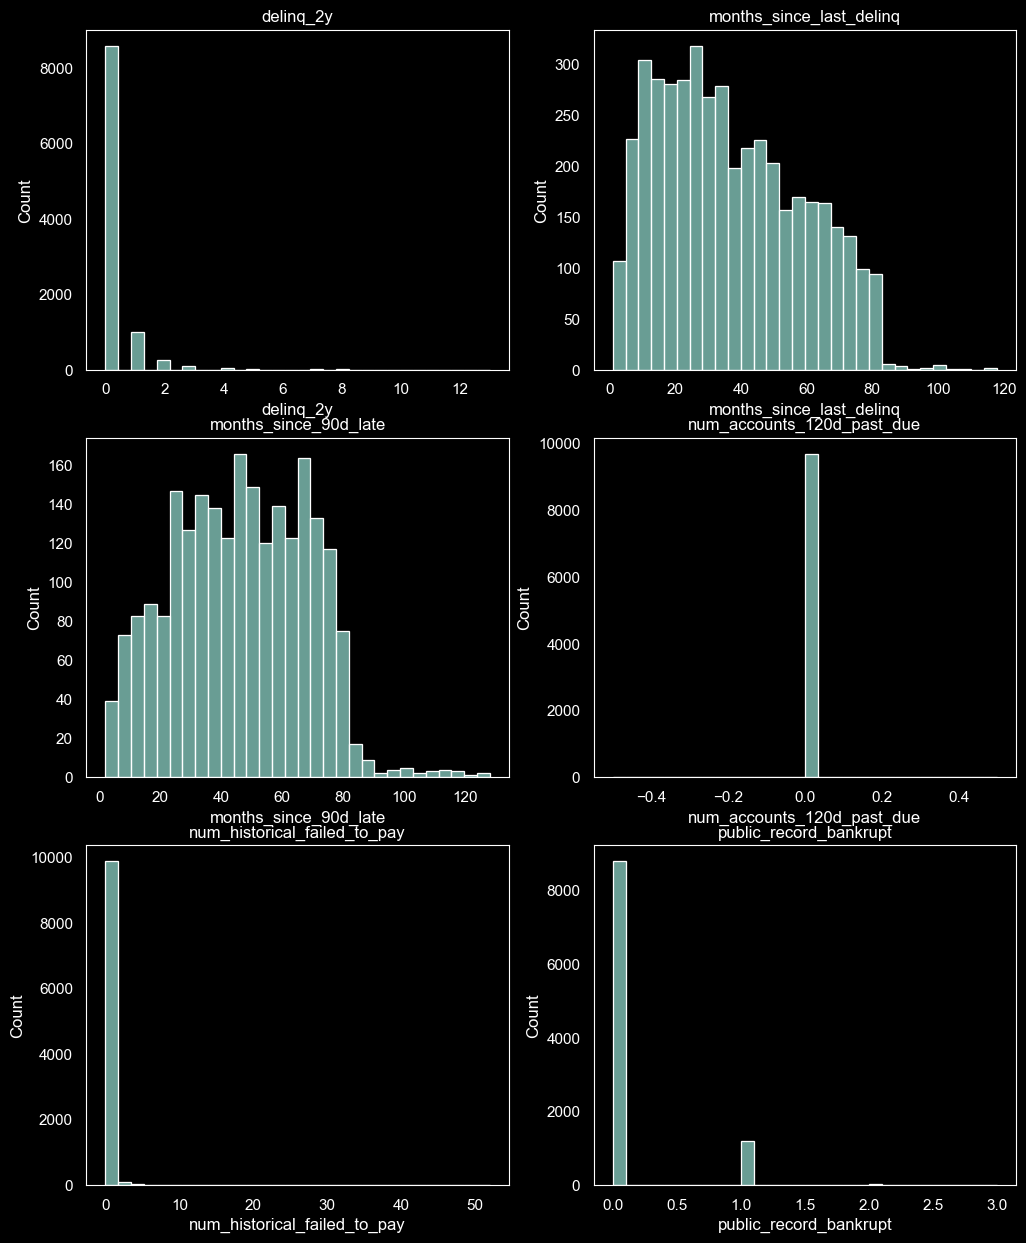

In [26]:
cols = ['delinq_2y','months_since_last_delinq','months_since_90d_late','num_accounts_120d_past_due','num_historical_failed_to_pay','public_record_bankrupt']
df_credit_history = pd.DataFrame(columns=[cols], index=['Describe', 'Information'])
# Grid size
n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], bins=30, ax=axes[i])
    axes[i].set_title(col)


**delinq_2y**-:Majority are financially stable, but a small risky group exists

**months_since_last_delinq**-:Borrowers either never defaulted or last default was long ago(majority of missing value which indiacates no delequency)

**months_since_90d_late**-:Severe delinquency is rare but when present, it's long-term behaviour(max no of days since 90 ddays late is 128)

**num_accounts_120d_past_due**-:This feature has no variability,most of the borrowers have 0 account that has passed 120 past due but there are 318 missing data that needs to be analysed further to determine the reason behind those missing data

**num_historical_failed_to_pay**-:Most people never failed
                              Few have extreme bad history
                              
**public_record_bankrupt**-:Few bankruptcies, but very impactful

**Missing data is most probably because those accounts never delinqued(not in the case of number of account 120 days past due)**

**raw numeric forms may be difficult to interpret directly, and supports transforming these variables into categorical risk groups (e.g., No Risk / Moderate Risk / High Risk) for more meaningful comparison.**


<Axes: xlabel='loan_amount', ylabel='Count'>

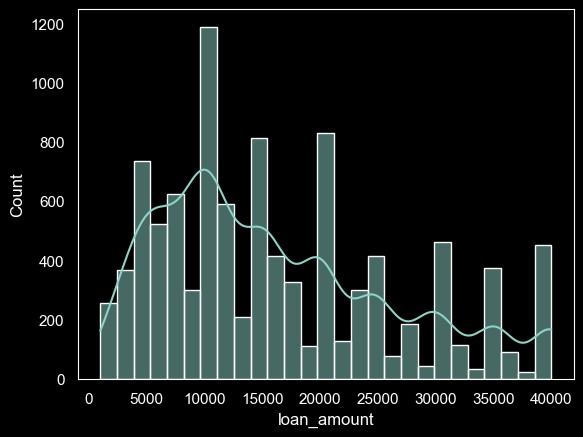

In [27]:
sns.histplot(data=df,x='loan_amount',kde=True)

The distribution of loan amounts is positively skewed, with the majority of loans concentrated between ₹5,000 and ₹15,000, and a peak around ₹10,000–₹12,000. The frequency of loans decreases as the loan amount increases, indicating that higher-value loans are less common.

In the subsequent analysis, we will focus on this dominant loan amount range and examine how key variables such as interest rate, annual income, and credit grade vary within it to better understand borrower risk characteristics.


## Credit Utilization & Exposure (Financial Pressure)(total_credit_limit,total_credit_utilized,credit_utilization ratio)

For better understanding creating new feature credit_utilization_ratio =total_credit_utilized/total_credit_limit

In [28]:
df['credit_utilization_ratio']=df['total_credit_utilized']/df['total_credit_limit']

In [29]:
cols = ['total_credit_limit','total_credit_utilized','credit_utilization_ratio']

desc = df[cols].describe().T

desc['non_null'] = df[cols].notnull().sum()
desc['missing'] = df[cols].isnull().sum()
desc['dtype'] = df[cols].dtypes


df_summary_Credit_Utilization_And_Exposure = desc
df_summary_Credit_Utilization_And_Exposure

,count,mean,std,min,25%,50%,75%,max,non_null,missing,dtype
total_credit_limit,10000.0,183606.230400,187632.707777,0.0,51593.750000,114667.000000,267550.000000,3.386034e+06,10000,0,int64
total_credit_utilized,10000.0,51049.063100,53636.731172,0.0,19185.500000,36927.000000,65421.000000,9.424560e+05,10000,0,int64
credit_utilization_ratio,9998.0,0.403158,0.269313,0.0,0.169029,0.360192,0.607317,1.835280e+00,9998,2,float64


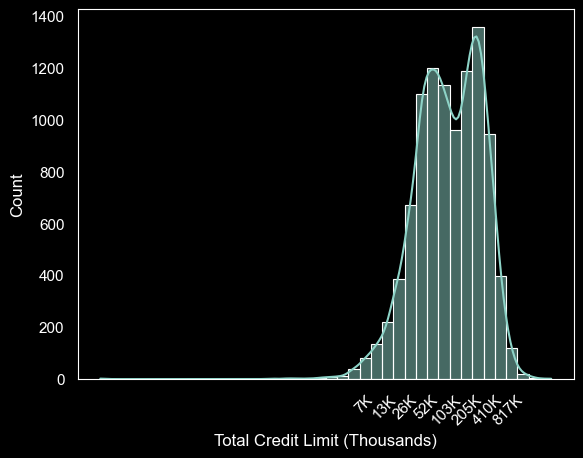

In [30]:
log_data = np.log1p(df['total_credit_limit'])

ax = sns.histplot(x=log_data, kde=True, bins=40)

ticks = np.linspace(
    np.log1p(df['total_credit_limit'].quantile(0.01)),
    np.log1p(df['total_credit_limit'].quantile(0.99)),
    8
)

labels = [f"{np.expm1(t)/1e3:.0f}K" for t in ticks]

ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax.set_xlabel("Total Credit Limit (Thousands)")
plt.xticks(rotation=45)
plt.show()

“Most borrowers fall within ₹51K–₹267K, with a median of ₹114K, indicating moderate credit capacity. However, a right-skewed distribution and a maximum of ₹3.38M reveal a small segment of high-exposure borrowers.

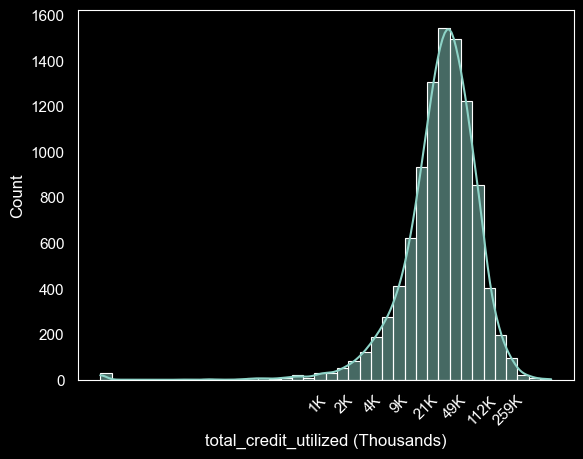

In [31]:
log_data = np.log1p(df['total_credit_utilized'])

ax = sns.histplot(x=log_data, kde=True, bins=40)

ticks = np.linspace(
    np.log1p(df['total_credit_utilized'].quantile(0.01)),
    np.log1p(df['total_credit_utilized'].quantile(0.99)),
    8
)

labels = [f"{np.expm1(t)/1e3:.0f}K" for t in ticks]

ax.set_xticks(ticks)
ax.set_xticklabels(labels)

ax.set_xlabel("total_credit_utilized (Thousands)")
plt.xticks(rotation=45)
plt.show()

“Median utilization is ₹36.9K (IQR: ₹19.2K–₹65.4K), with right skew (mean ₹51K) and extremes up to ₹9.4L indicating a small high-risk group.

Although total credit limit and credit limit utilized gives us some idea about borrowers risk behaviour but does not tell any thing very conclusive for that we will used new engineered feauture 'credit_utilization_ratio'

In [32]:
df['total_credit_utilized'].quantile(0.01)

np.float64(752.0)

In [33]:
df['credit_utilization_ratio'].describe()

count    9998.000000
mean        0.403158
std         0.269313
min         0.000000
25%         0.169029
50%         0.360192
75%         0.607317
max         1.835280
Name: credit_utilization_ratio, dtype: float64

(array([0.        , 0.13636364, 0.27272727, 0.40909091, 0.54545455,
        0.68181818, 0.81818182, 0.95454545, 1.09090909, 1.22727273,
        1.36363636, 1.5       ]),
 [Text(0.0, 0, '0.000'),
  Text(0.13636363636363635, 0, '0.136'),
  Text(0.2727272727272727, 0, '0.273'),
  Text(0.40909090909090906, 0, '0.409'),
  Text(0.5454545454545454, 0, '0.545'),
  Text(0.6818181818181818, 0, '0.682'),
  Text(0.8181818181818181, 0, '0.818'),
  Text(0.9545454545454545, 0, '0.955'),
  Text(1.0909090909090908, 0, '1.091'),
  Text(1.227272727272727, 0, '1.227'),
  Text(1.3636363636363635, 0, '1.364'),
  Text(1.5, 0, '1.500')])

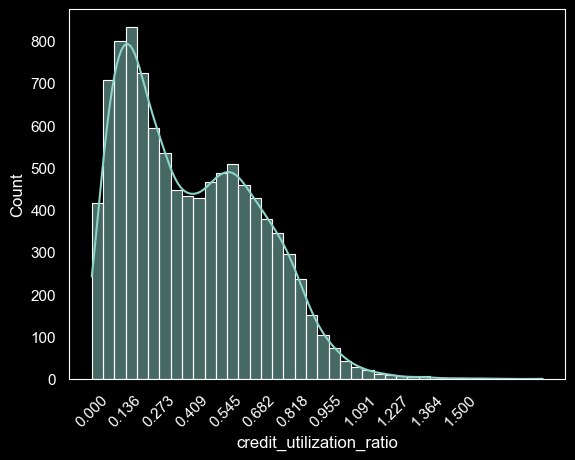

In [34]:

ax=sns.histplot(df['credit_utilization_ratio'],kde=True,bins=40)
ticks=np.linspace(0,1.5,12)
ax.set_xticks(ticks)
plt.xticks(rotation=45)


The credit utilization ratio shows a median of 0.36, with 50% of borrowers ranging between 0.17 and 0.61, indicating generally moderate utilization levels. The mean (0.40) is slightly above the median, suggesting mild right skew, driven by a smaller group of higher-utilization borrowers.

While most borrowers appear to maintain manageable credit usage, ratios above 1.0 (up to 1.83) indicate over-utilization, highlighting a small but potentially high-risk segment under financial stress.

This suggests credit utilization may provide a more behaviorally meaningful indicator of borrower risk than credit limit or utilized credit alone, and warrants further analysis against delinquency, grade, and interest rate.

## Loan Characteristics

To assess how lender-assigned pricing and grading reflect the intrinsic risk level of loans (Interest Rate, Grade, Sub-grade)

In [35]:
df['interest_rate'].describe()

count    10000.000000
mean        12.427524
std          5.001105
min          5.310000
25%          9.430000
50%         11.980000
75%         15.050000
max         30.940000
Name: interest_rate, dtype: float64

<Axes: xlabel='interest_rate', ylabel='Count'>

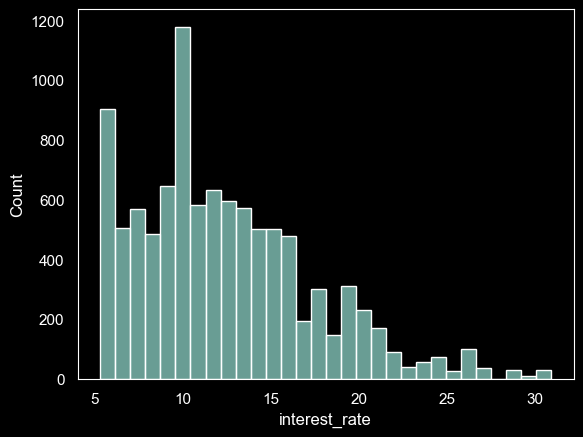

In [36]:
sns.histplot(data=df,x='interest_rate' ,bins=30)

“Most loans are issued between 5% and 15%, with a right-skewed distribution. Higher interest rates may indicate higher-risk borrowers, which we will further validate by comparing with grade, debt-to-equity, and credit utilization.”

Analysing Grade / Sub_grade

<Axes: xlabel='grade', ylabel='count'>

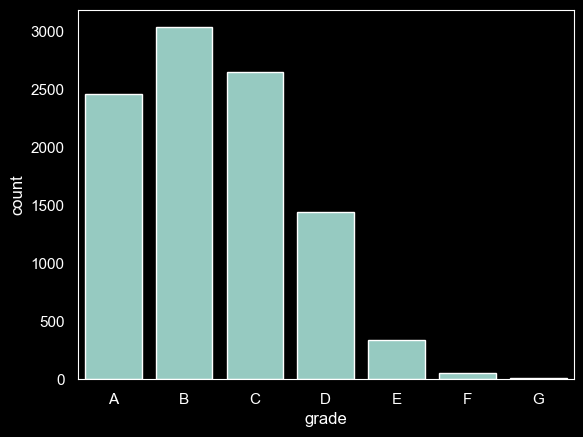

In [37]:
order = sorted(df['grade'].unique())
sns.countplot(data=df,x='grade',order=order)

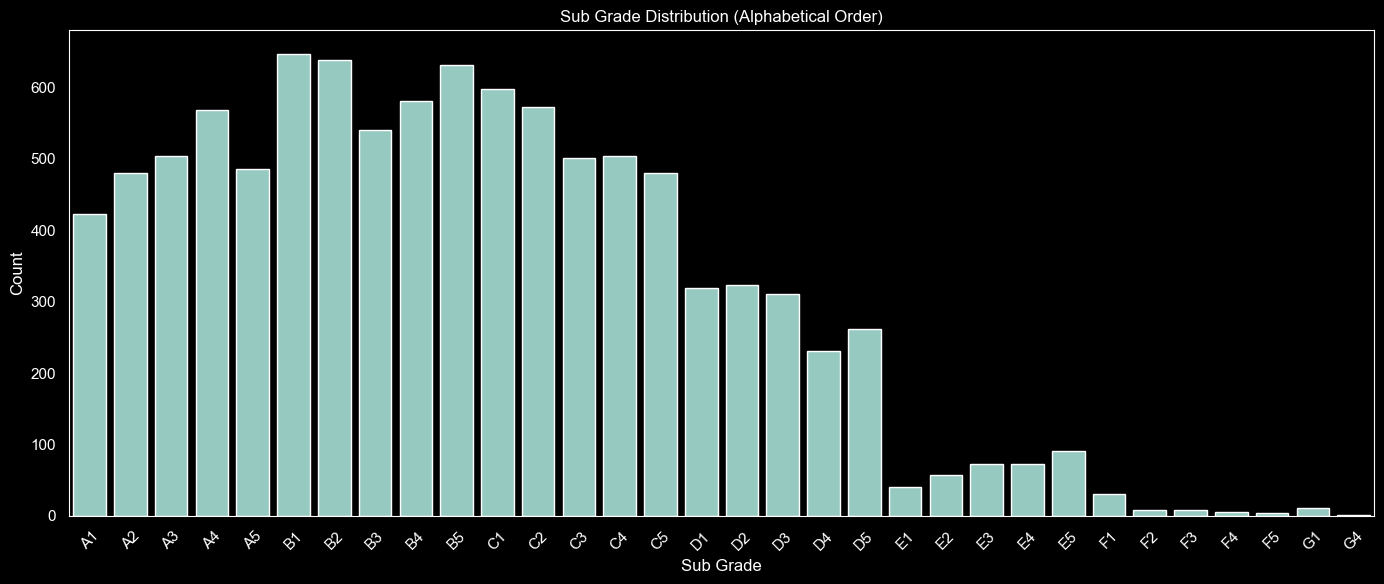

In [38]:
order = sorted(df['sub_grade'].unique(), key=lambda x: (x[0], int(x[1])))

plt.figure(figsize=(14,6))
sns.countplot(x='sub_grade', data=df, order=order)

plt.xticks(rotation=45)
plt.title("Sub Grade Distribution (Alphabetical Order)")
plt.xlabel("Sub Grade")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

“The distribution of grades and sub-grades indicates a strong concentration of borrowers in the B and C categories, reflecting a lending preference toward moderate-risk segments. While high-risk grades (E–G) are minimally represented, the granular sub-grade distribution highlights that risk is primarily concentrated within mid-tier borrowers, making them critical for default analysis.”



## **Multivariate Analysis**

In [39]:
df.columns

Index(['Unnamed: 0', 'emp_title', 'emp_length', 'state', 'homeownership',
       'annual_income', 'verified_income', 'debt_to_income',
       'annual_income_joint', 'verification_income_joint',
       'debt_to_income_joint', 'delinq_2y', 'months_since_last_delinq',
       'earliest_credit_line', 'inquiries_last_12m', 'total_credit_lines',
       'open_credit_lines', 'total_credit_limit', 'total_credit_utilized',
       'num_collections_last_12m', 'num_historical_failed_to_pay',
       'months_since_90d_late', 'current_accounts_delinq',
       'total_collection_amount_ever', 'current_installment_accounts',
       'accounts_opened_24m', 'months_since_last_credit_inquiry',
       'num_satisfactory_accounts', 'num_accounts_120d_past_due',
       'num_accounts_30d_past_due', 'num_active_debit_accounts',
       'total_debit_limit', 'num_total_cc_accounts', 'num_open_cc_accounts',
       'num_cc_carrying_balance', 'num_mort_accounts',
       'account_never_delinq_percent', 'tax_liens', 'publi

Borrower Financial Strength (Ability to Pay)

annual_income/annual_income_joint(annual income joint is insignificant in numbers so there is no point analysing its distribution but we analyse borrowers behaviour for joint annual income same goes with other feautures dealing with joint account )(done)
verified_income / verification_income_joint(done)
debt_to_income / debt_to_income_joint(done)
installment(done)
Credit History & Past Behavior

delinq_2y
months_since_last_delinq
months_since_90d_late
num_accounts_120d_past_due
num_historical_failed_to_pay
public_record_bankrupt
Credit Utilization & Exposure (Financial Pressure)

total_credit_limit
total_credit_utilized
credit_utilization ratio
Credit Activity & Inquiry Behavior

inquiries_last_12m
months_since_last_credit_inquiry
earliest_credit_line
Loan Characteristics (Loan Risk Itself)

interest_rate ⭐
installment
grade / sub_grade

“The analysis begins by examining the historical risk behavior of borrowers using delinquency-related variables. This behavior is then linked to financial capacity indicators such as debt-to-income ratio, annual income, and income verification status to understand whether weaker financial profiles correspond to higher risk. Further, the alignment between past risk behavior and loan characteristics such as interest rate, term, and credit grade is evaluated. Finally, the impact of application type (individual vs joint) on borrower risk is assessed.”

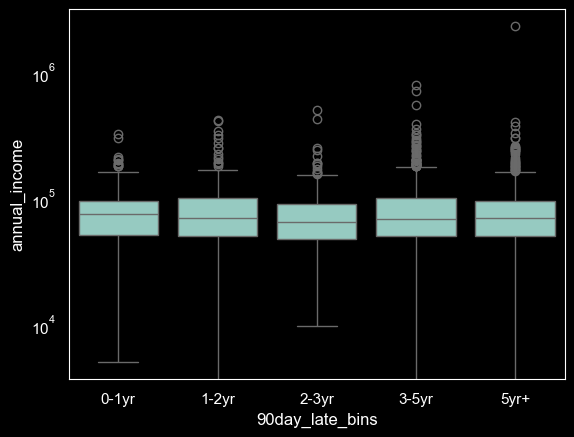

In [40]:
df['90day_late_bins'] = pd.cut(
     df['months_since_90d_late'],
     bins=[0,12,24,36,60,120],
     labels=['0-1yr','1-2yr','2-3yr','3-5yr','5yr+']
)

sns.boxplot(data=df, x='90day_late_bins', y='annual_income')
plt.yscale('log')

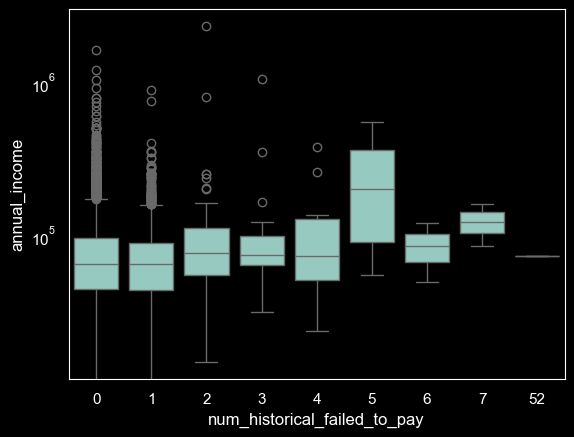

In [41]:
sns.boxplot(data=df,x='num_historical_failed_to_pay',y='annual_income')
plt.yscale('log')


“Across multiple credit risk indicators—recent delinquencies, recency of severe delinquency, and historical payment failures—income shows no strong or consistent relationship with borrower risk. This suggests that income alone is not a reliable predictor of credit behavior.”

C:\Users\abdur\AppData\Local\Temp\ipykernel_20516\1164313499.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(labels)


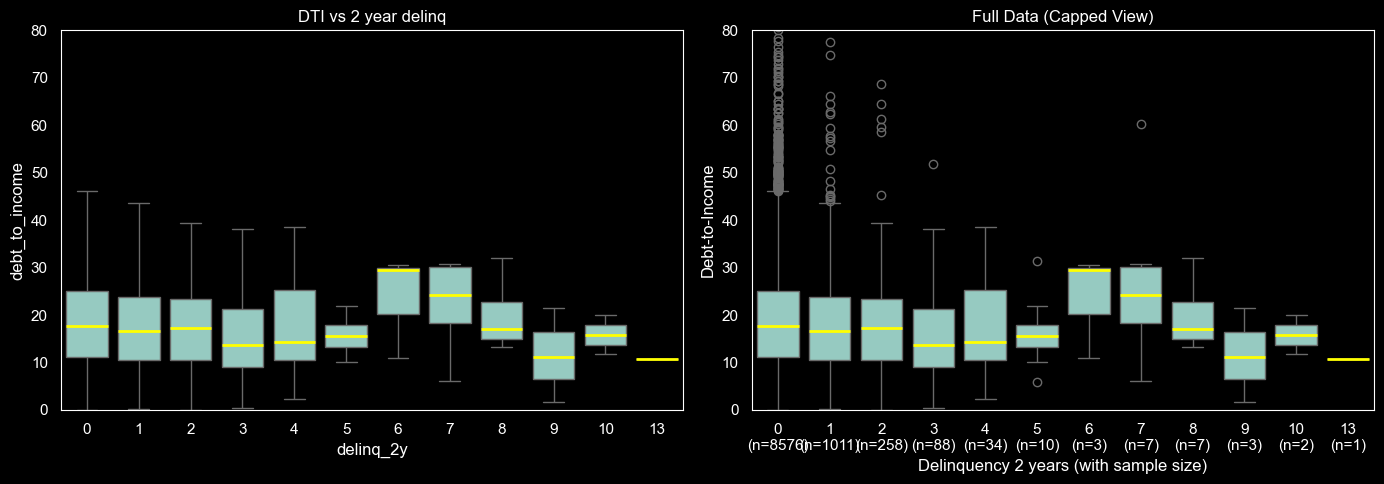

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(
    data=df,
    x='delinq_2y',
    y='debt_to_income',
    ax=axes[0],
    showfliers=False,
    medianprops={"color": "yellow", "linewidth": 2}
)
axes[0].set_title("DTI vs 2 year delinq")
axes[0].set_ylim(0, 80)

counts = df['delinq_2y'].value_counts().sort_index()

sns.boxplot(
    data=df,
    x='delinq_2y',
    y='debt_to_income',
    ax=axes[1],
    showfliers=True,
    medianprops={"color": "yellow", "linewidth": 2}
)

axes[1].set_title("Full Data (Capped View)")
axes[1].set_ylim(0, 80)

#Add counts to x-axis labels
labels = [f"{i}\n(n={counts.get(i,0)})" for i in sorted(df['delinq_2y'].unique())]
axes[1].set_xticklabels(labels)

axes[1].set_xlabel("Delinquency 2 years (with sample size)")
axes[1].set_ylabel("Debt-to-Income")

plt.tight_layout()



“Debt-to-income ratio does not show a strong monotonic relationship with delinquency in the reliable range (0–4). Apparent increases at higher delinquency levels are driven by very small sample sizes and should not be interpreted as a true pattern."

In [43]:
df['delinq_2y'].value_counts().sort_index()

delinq_2y
0     8576
1     1011
2      258
3       88
4       34
5       10
6        3
7        7
8        7
9        3
10       2
13       1
Name: count, dtype: int64

In [44]:
 df['months_since_last_delinq'].value_counts().sort_index()

months_since_last_delinq
1.0       6
2.0      12
3.0      36
4.0      53
5.0      47
         ..
101.0     2
102.0     1
106.0     1
109.0     1
118.0     2
Name: count, Length: 97, dtype: int64

In [45]:
df['months_since_90d_late'].value_counts().sort_index()

months_since_90d_late
2.0       1
3.0       6
4.0       8
5.0       9
6.0      15
         ..
113.0     1
115.0     1
118.0     3
120.0     1
128.0     2
Name: count, Length: 106, dtype: int64

In [46]:
df['num_accounts_120d_past_due'].value_counts().sort_index()

num_accounts_120d_past_due
0.0    9682
Name: count, dtype: int64

In [47]:
df['num_historical_failed_to_pay'].value_counts().sort_index()

num_historical_failed_to_pay
0     8586
1     1288
2       78
3       27
4       12
5        4
6        2
7        2
52       1
Name: count, dtype: int64

In [48]:
df['public_record_bankrupt'].value_counts().sort_index()

public_record_bankrupt
0    8785
1    1195
2      17
3       3
Name: count, dtype: int64

In [49]:
df['loan_status'].value_counts().sort_index()

loan_status
Charged Off              7
Current               9375
Fully Paid             447
In Grace Period         67
Late (16-30 days)       38
Late (31-120 days)      66
Name: count, dtype: int64

“Since several risk-related variables are highly skewed and concentrated at lower values, they should transformed into categorical risk groups to improve interpretability and enable meaningful comparison across borrower segments.”

In [50]:
#Gruping delequencies in no risk,moderate risk and high risk

In [51]:
def classify_risk(x):
    if x == 0:
        return 'No Risk'
    elif x <= 2:
        return 'Moderate Risk'
    else:
        return 'High Risk'
df['delinq2year_risk'] = df['delinq_2y'].apply(classify_risk)

In [52]:
def delinq_recency(x):
    if pd.isna(x):
        return 'No History (Safe)'
    elif x <= 6:
        return 'Recent Risk'
    elif x <= 24:
        return 'Moderate Risk'
    else:
        return 'Low Risk'

df['delinq_recency_group'] = df['months_since_last_delinq'].apply(delinq_recency)

In [53]:
def late90_recency(x):
    if pd.isna(x):
        return 'No Severe History (Safe)'
    elif x <= 6:
        return 'Very High Risk'
    elif x <= 24:
        return 'High Risk'
    else:
        return 'Moderate Risk'

df['late90_group'] = df['months_since_90d_late'].apply(late90_recency)

In [54]:
def failed_payments(x):
    if x == 0:
        return 'No Risk'
    elif x <= 2:
        return 'Moderate Risk'
    else:
        return 'High Risk'

df['failed_pay_group'] = df['num_historical_failed_to_pay'].apply(failed_payments)

In [55]:
def bankruptcy_risk(x):
    if x == 0:
        return 'No Bankruptcy (Safe)'
    elif x == 1:
        return 'Bankruptcy History'
    else:
        return 'Multiple Bankruptcies (High Risk)'

df['bankrupt_group'] = df['public_record_bankrupt'].apply(bankruptcy_risk)

In [56]:
#Validating whaether  interest rate is indicator of risk behaviour or not

<Axes: xlabel='grade', ylabel='interest_rate'>

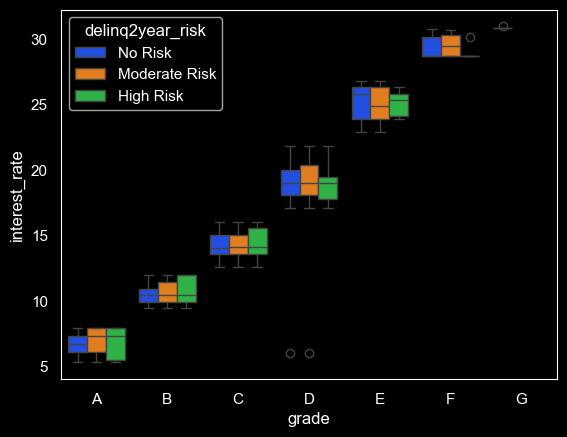

In [57]:
sns.boxplot(
    data=df,
    x='grade',
    y='interest_rate',
    hue='delinq2year_risk',
    order=['A','B','C','D','E','F','G'],
    palette='bright'
)

<Axes: xlabel='grade', ylabel='interest_rate'>

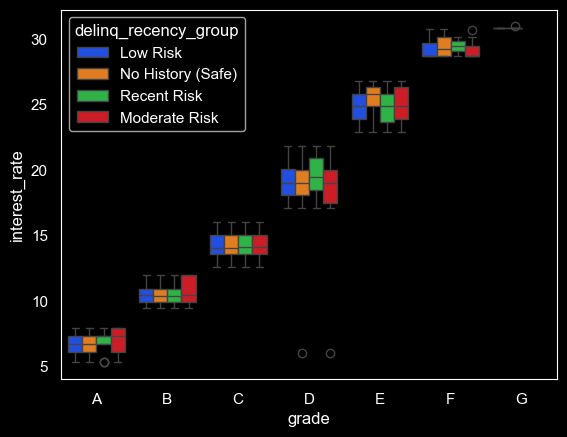

In [58]:
sns.boxplot(
    data=df,
    x='grade',
    y='interest_rate',
    hue='delinq_recency_group',
    order=['A','B','C','D','E','F','G'],
    palette='bright'
)

“While delinquency risk shows only minor and inconsistent variation in interest rates within each credit grade, the differences are negligible. This suggests that credit grade is the primary determinant of interest rate, and delinquency risk is largely already captured within the grading system. Therefore, interest rate should not be considered a standalone or pure indicator of borrower risk, but rather as a pricing outcome based on assessed risk.

In [60]:
#Exploring risk behaviour category

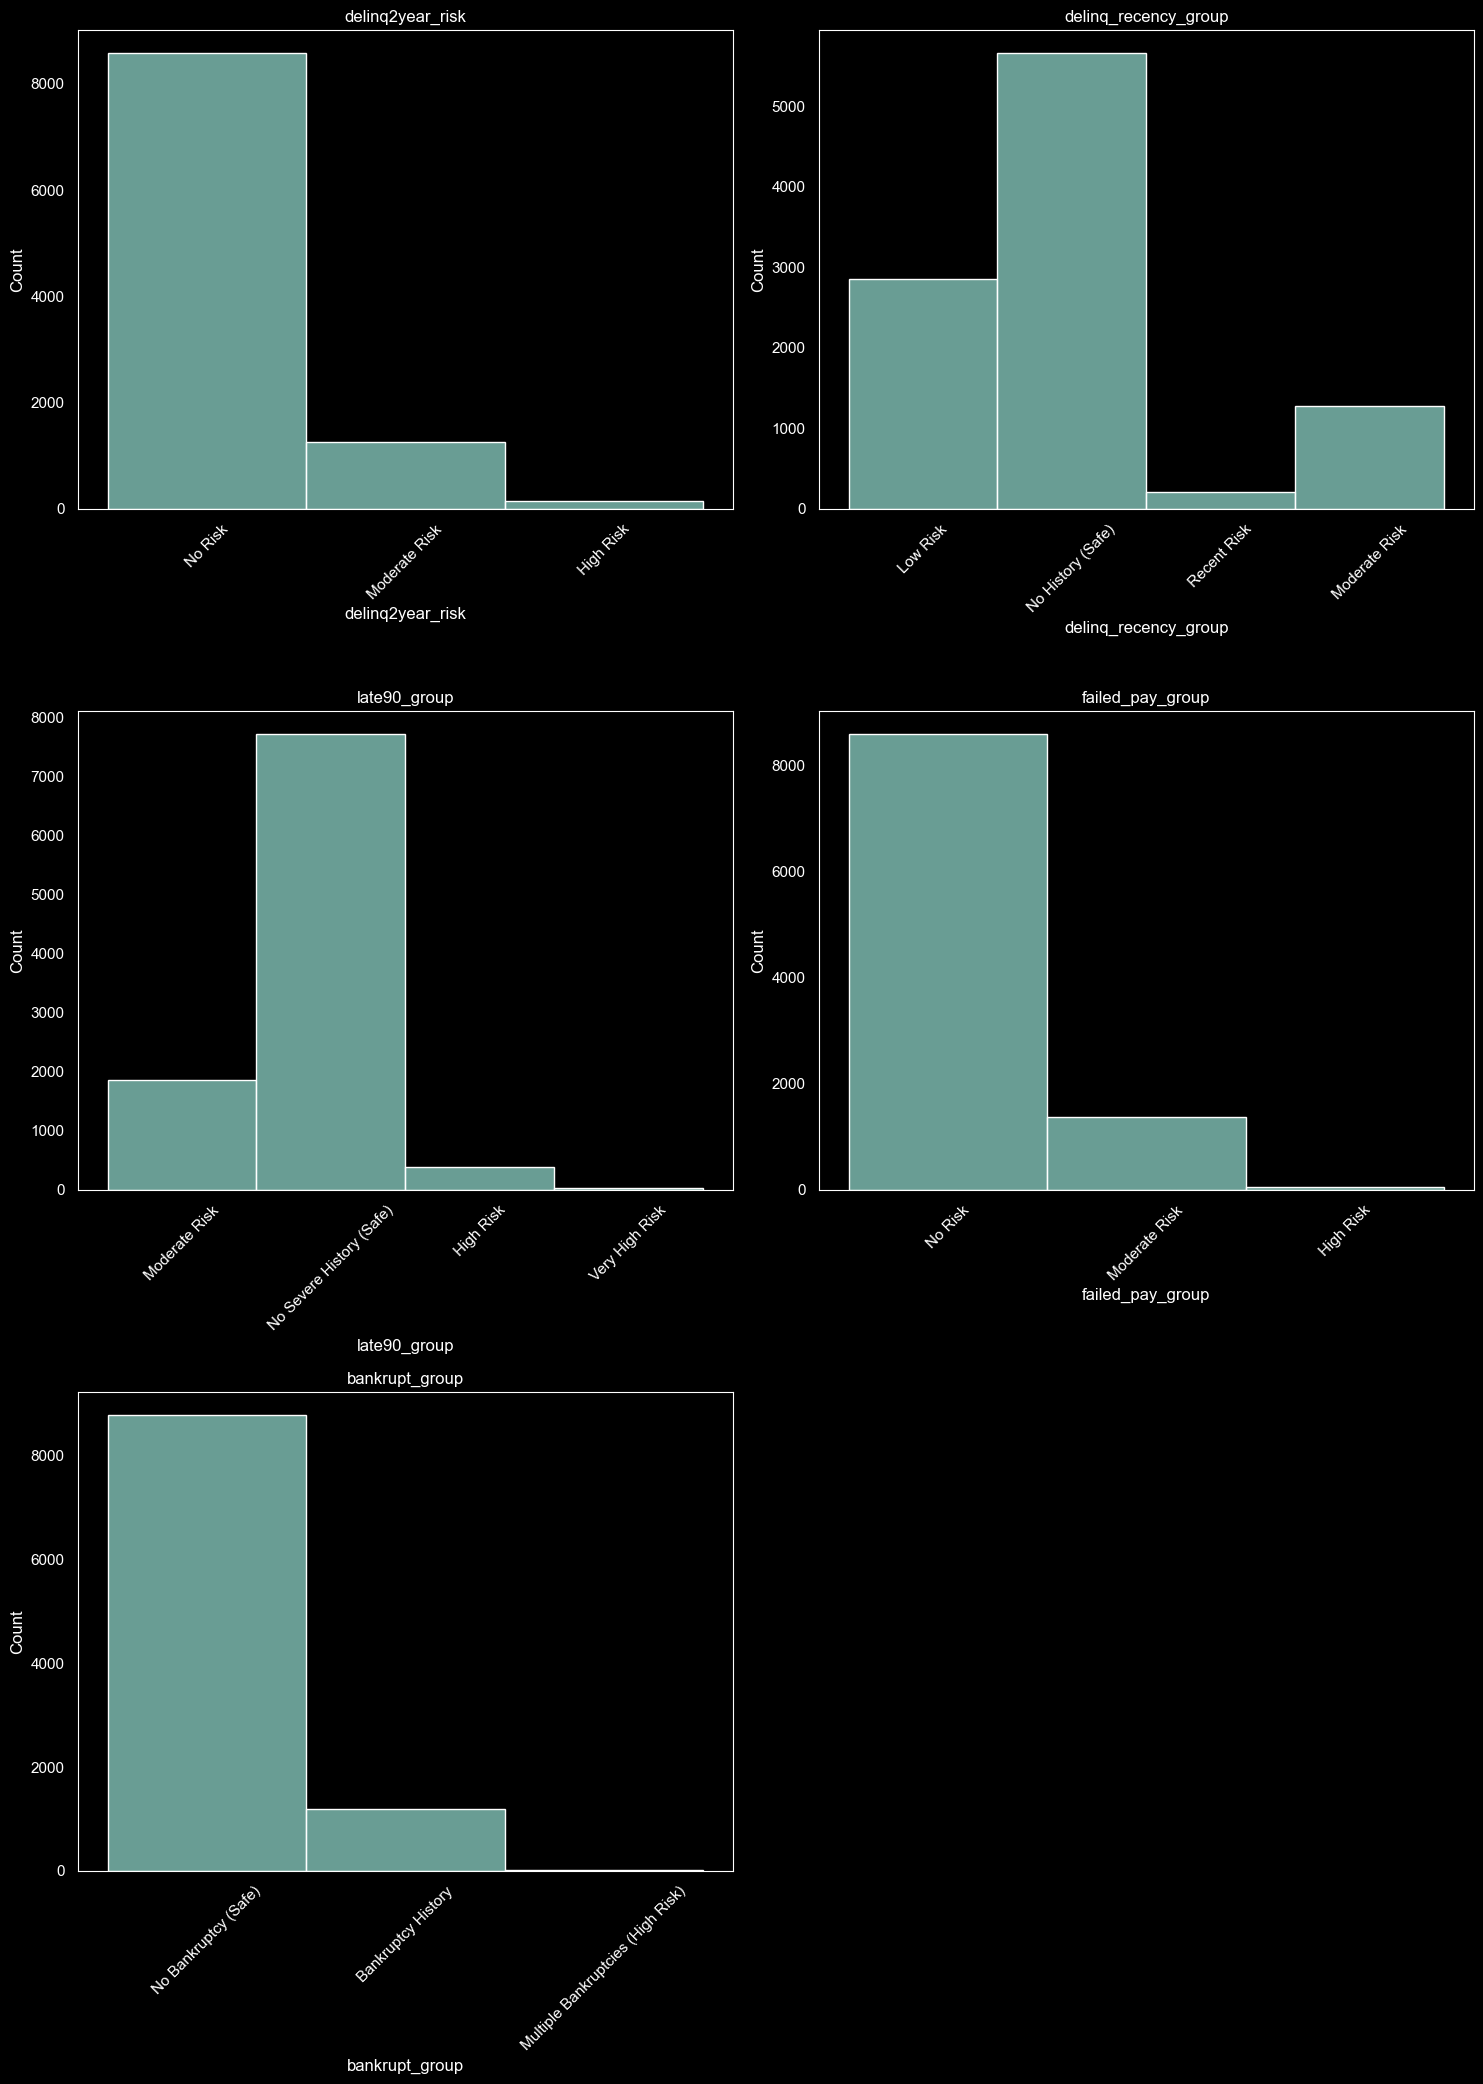

In [61]:
cols = ['delinq2year_risk','delinq_recency_group','late90_group','failed_pay_group','bankrupt_group']
n_cols = 2
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 7* n_rows))
axes = axes.flatten()
plt.xticks(rotation=45)
for i, col in enumerate(cols):
    sns.histplot(df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()

In [62]:
#Converting all the risk behaviour indicator into one composite indicator

In [63]:
delinq_map = {
    'No Risk': 0,
    'Moderate Risk': 1,
    'High Risk': 2
}
recency_map = {
    'No History (Safe)': 0,
    'Low Risk': 1,
    'Moderate Risk': 2,
    'Recent Risk': 3
}
late90_map = {
    'No Severe History (Safe)': 0,
    'Moderate Risk': 1,
    'High Risk': 2,
    'Very High Risk': 3
}


failed_map = {
    'No Risk': 0,
    'Moderate Risk': 1,
    'High Risk': 2
}
bankrupt_map = {
    'No Bankruptcy (Safe)': 0,
    'Bankruptcy History': 2,
    'Multiple Bankruptcies (High Risk)': 3
}

In [64]:
df['delinq_score'] = df['delinq2year_risk'].map(delinq_map)
df['recency_score'] = df['delinq_recency_group'].map(recency_map)
df['late90_score'] = df['late90_group'].map(late90_map)
df['failed_score'] = df['failed_pay_group'].map(failed_map)
df['bankrupt_score'] = df['bankrupt_group'].map(bankrupt_map)

In [65]:
#composite risk score(Weighted)

In [66]:
df['risk_score'] = (
    df['delinq_score']  +
    df['recency_score']  +
    df['late90_score']  +
    df['failed_score']  +
    df['bankrupt_score'] 
)

In [67]:
#Converting risk score to categories 

In [68]:
def final_risk(x):
    if x <= 2:
        return 'Low Risk'
    elif x <= 5:
        return 'Moderate Risk'
    else:
        return 'High Risk'

df['overall_risk'] = df['risk_score'].apply(final_risk)

<Axes: xlabel='overall_risk', ylabel='count'>

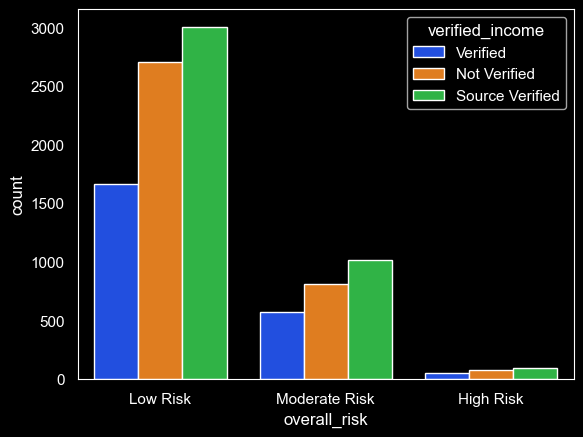

In [69]:
sns.countplot(data=df,x='overall_risk',hue='verified_income',palette='bright')

In [70]:
#Validating wheather overall _risk (composite risk category) can be treated as major risk indicator or not

<Axes: xlabel='overall_risk', ylabel='interest_rate'>

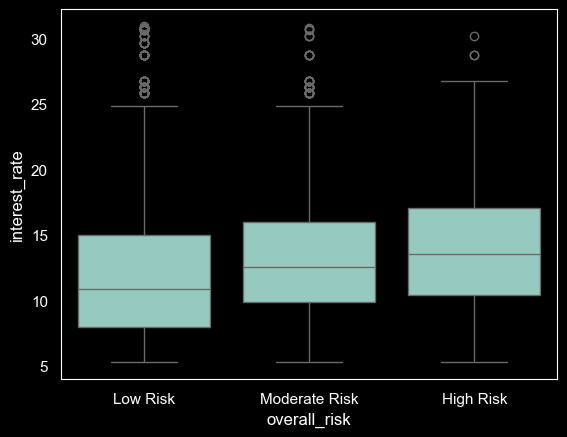

In [71]:
sns.boxplot(x='overall_risk', y='interest_rate', data=df)

In [72]:
df.groupby('overall_risk')['interest_rate'].agg(['mean','median'])

,mean,median
overall_risk,,
High Risk,14.303172,13.59
Low Risk,12.102466,10.91
Moderate Risk,13.252559,12.61


In [73]:
df.groupby('failed_pay_group')['interest_rate'].agg(['mean','median'])

,mean,median
failed_pay_group,,
High Risk,13.007292,12.61
Moderate Risk,13.094356,12.61
No Risk,12.318192,11.98


“Although the composite overall_risk feature shows a consistent increase in interest rates across risk categories, the magnitude of difference is relatively small, indicating limited discriminatory power as a primary risk indicator. However, it captures meaningful behavioral patterns and is therefore useful for analyzing and profiling the drivers of risky borrower behavior.”

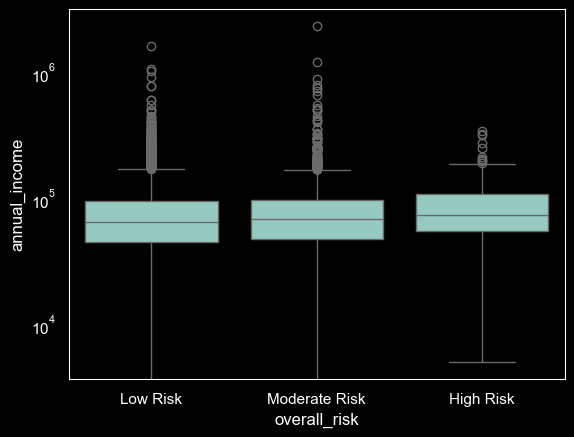

In [74]:
sns.boxplot(x='overall_risk', y='annual_income', data=df)
plt.yscale('log')

In [75]:
df.groupby('overall_risk')['annual_income'].agg(['mean','median'])

,mean,median
overall_risk,,
High Risk,87135.175815,73000.0
Low Risk,77892.456194,65000.0
Moderate Risk,82574.239147,68000.0


In [76]:
df['income_band'] = pd.qcut(df['annual_income'], q=5)

pd.crosstab(
    df['income_band'],
    df['overall_risk'],
    normalize='index'
)*100

overall_risk,High Risk,Low Risk,Moderate Risk
income_band,,,
"(-0.001, 40521.6]",1.050000,76.350000,22.600000
"(40521.6, 58000.0]",2.389248,74.713788,22.896964
"(58000.0, 75000.0]",2.591894,73.374175,24.033930
"(75000.0, 104000.0]",2.330508,71.769068,25.900424
"(104000.0, 2300000.0]",2.978294,72.741040,24.280666


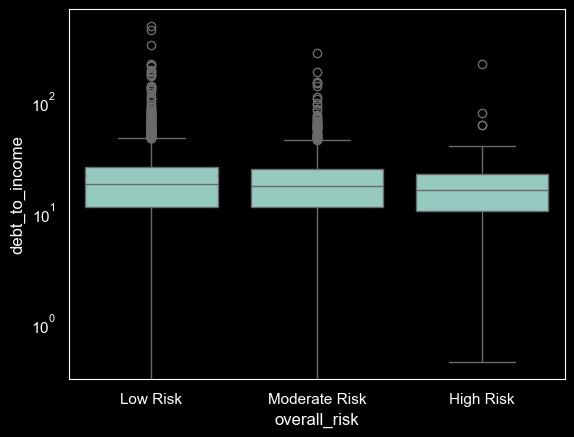

In [77]:
sns.boxplot(x='overall_risk', y='debt_to_income', data=df)
plt.yscale('log')

In [78]:
df.groupby('overall_risk')['debt_to_income'].agg(['mean','median'])

,mean,median
overall_risk,,
High Risk,18.134581,15.88
Low Risk,19.458013,17.79
Moderate Risk,18.957510,17.24


In [79]:
df['debt_to_income_band'] = pd.qcut(df['debt_to_income'], q=5)

pd.crosstab(
    df['debt_to_income_band'],
    df['overall_risk'],
    normalize='index'
) * 100

overall_risk,High Risk,Low Risk,Moderate Risk
debt_to_income_band,,,
"(-0.001, 9.7]",2.652653,73.673674,23.673674
"(9.7, 15.08]",2.759659,72.453588,24.786754
"(15.08, 20.25]",2.300000,71.350000,26.350000
"(20.25, 27.03]",1.807229,75.702811,22.489960
"(27.03, 469.09]",1.856498,75.865529,22.277973


In [80]:
ct = pd.crosstab(df['overall_risk'], df['verified_income'], normalize='index') * 100
ct

verified_income,Not Verified,Source Verified,Verified
overall_risk,,,
High Risk,34.361233,42.731278,22.907489
Low Risk,36.688796,40.726189,22.585016
Moderate Risk,33.779264,42.349498,23.871237


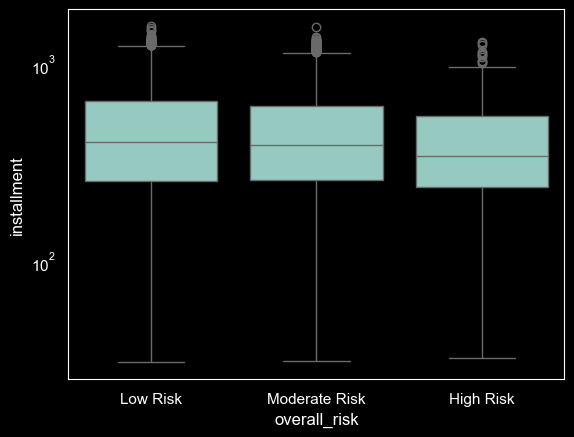

In [81]:
sns.boxplot(x='overall_risk', y='installment', data=df)
plt.yscale('log')

In [82]:
df.groupby('overall_risk')['installment'].agg(['mean','median'])

,mean,median
overall_risk,,
High Risk,425.648106,342.120
Low Risk,482.135707,403.490
Moderate Risk,462.703788,388.855


In [83]:
df['installment_band']=pd.qcut(df['installment'],q=5)
pd.crosstab(df['installment_band'],df['overall_risk'],normalize='index')*100

overall_risk,High Risk,Low Risk,Moderate Risk
installment_band,,,
"(30.749, 222.374]",2.550000,74.700000,22.750000
"(222.374, 335.12]",2.929494,71.002979,26.067527
"(335.12, 486.98]",2.309237,72.088353,25.602410
"(486.98, 713.332]",1.805416,73.721163,24.473420
"(713.332, 1566.59]",1.750000,77.550000,20.700000


In [84]:
df['overall_risk'].value_counts()

overall_risk
Low Risk         7381
Moderate Risk    2392
High Risk         227
Name: count, dtype: int64

<Axes: xlabel='overall_risk', ylabel='credit_utilization_ratio'>

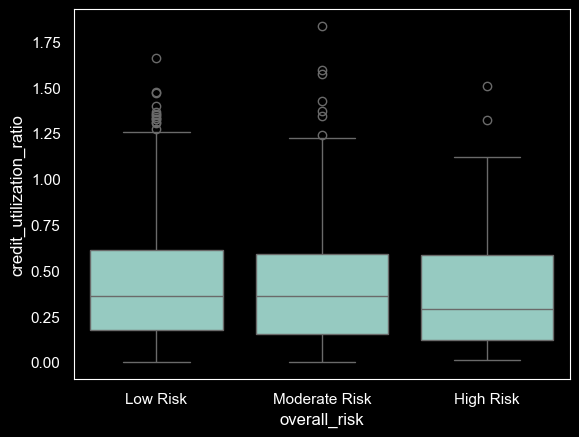

In [85]:
sns.boxplot(x='overall_risk', y='credit_utilization_ratio', data=df)

In [86]:
df.groupby('overall_risk')['credit_utilization_ratio'].agg(['mean','median'])

,mean,median
overall_risk,,
High Risk,0.361893,0.289503
Low Risk,0.407116,0.363829
Moderate Risk,0.394861,0.359569


In [87]:
df['credit_utilisation_ratio_band']=pd.qcut(df['credit_utilization_ratio'],q=5)
pd.crosstab(
    df['credit_utilisation_ratio_band'],
    df['overall_risk'],
    normalize='index'
) * 100

overall_risk,High Risk,Low Risk,Moderate Risk
credit_utilisation_ratio_band,,,
"(-0.001, 0.142]",3.400000,70.850000,25.750000
"(0.142, 0.27]",1.950975,75.437719,22.611306
"(0.27, 0.467]",2.400000,74.200000,23.400000
"(0.467, 0.658]",1.650825,72.936468,25.412706
"(0.658, 1.835]",1.950000,75.600000,22.450000


In [88]:
pd.crosstab(
    df['income_band'],
    df['grade'],
    normalize='index'
)*100

grade,A,B,C,D,E,F,G
income_band,,,,,,,
"(-0.001, 40521.6]",18.150000,30.050000,28.500000,17.850000,4.850000,0.500000,0.100000
"(40521.6, 58000.0]",23.195620,29.268293,27.127924,16.127427,3.534097,0.647088,0.099552
"(58000.0, 75000.0]",24.128181,30.065975,27.238454,14.655985,3.110273,0.706880,0.094251
"(75000.0, 104000.0]",26.218220,30.720339,26.112288,13.771186,2.542373,0.423729,0.211864
"(104000.0, 2300000.0]",31.448763,31.802120,23.573953,9.793034,2.675416,0.605755,0.100959


In [89]:
df['interest_band']=pd.qcut(df['interest_rate'],q=5)
pd.crosstab(
    df['income_band'],
    df['interest_band'],
    normalize='index'
)*100

interest_band,"(5.308999999999999, 7.96]","(7.96, 10.42]","(10.42, 12.62]","(12.62, 16.02]","(16.02, 30.94]"
income_band,,,,,
"(-0.001, 40521.6]",15.250000,19.300000,19.100000,23.050000,23.300000
"(40521.6, 58000.0]",20.159283,20.209059,17.471379,21.752115,20.408163
"(58000.0, 75000.0]",21.536287,21.866164,16.635250,21.489161,18.473139
"(75000.0, 104000.0]",23.675847,21.716102,18.432203,19.226695,16.949153
"(104000.0, 2300000.0]",28.924785,21.857648,18.929833,17.112569,13.175164


Income does not appear strongly aligned with the constructed overall risk measure, but it shows a clearer inverse relationship with interest-rate bands, suggesting income may influence loan pricing more than borrower behavioral risk.

In [90]:
pd.crosstab(
    df['interest_band'],
    df['overall_risk'],
    normalize='index'
)*100

overall_risk,High Risk,Low Risk,Moderate Risk
interest_band,,,
"(5.308999999999999, 7.96]",0.640146,84.270690,15.089163
"(7.96, 10.42]",2.143878,73.749404,24.106717
"(10.42, 12.62]",2.377004,71.475954,26.147043
"(12.62, 16.02]",3.064202,69.941634,26.994163
"(16.02, 30.94]",3.353164,68.090860,28.555976


In [91]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['interest_band'], df['overall_risk'])

chi2, p, dof, expected = chi2_contingency(table)

print(p)

3.4141899143725103e-36


I began by analyzing the relationship between annual income, debt-to-income ratio (DTI), and installment amounts against overall risk behavior. The results showed that DTI, income, and installment had weak associations with overall risk, and in some cases the patterns appeared counterintuitive, with higher financial burden not consistently corresponding to higher risk.

To investigate these unexpected results further, I explored possible underlying explanations. This led me to analyze overall risk against interest rates, where I found a much clearer pattern: risk behavior appears to align strongly with increasing interest rates, with higher-rate borrowers showing greater proportions of moderate and high risk, and fewer low-risk borrowers.

This suggests that interest rate may be a stronger indicator of borrower risk behavior than income, DTI, or installment levels, which may be influenced by confounding factors or underwriting effects.

Either  higher interest rate is decided based on the risky behaviour or risky behaviour is shown because of higher interest rate

<Axes: xlabel='overall_risk', ylabel='count'>

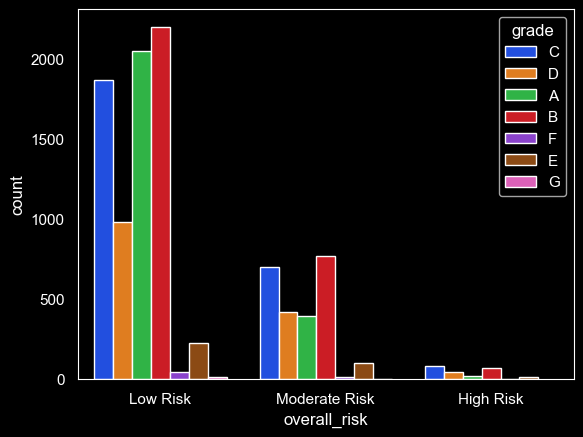

In [92]:
sns.countplot(x='overall_risk', hue='grade', data=df,palette='bright')

In [93]:
pd.crosstab(
    df['grade'],
    df['overall_risk'],
    normalize='index'
)*100

overall_risk,High Risk,Low Risk,Moderate Risk
grade,,,
A,0.650671,83.407889,15.941440
B,2.304906,72.406981,25.288113
C,2.977761,70.523935,26.498304
D,3.250346,67.911480,28.838174
E,3.582090,66.567164,29.850746
F,5.172414,75.862069,18.965517
G,0.000000,91.666667,8.333333


In [94]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['grade'], df['overall_risk'])
chi2, p, dof, exp = chi2_contingency(table)
print(p)

1.522423669839905e-33


Since safer grades contain more low-risk borrowers and riskier grades contain more moderate/high-risk borrowers, and the Chi-square test confirms this relationship, the overall risk variable appears to be a meaningful measure of borrower risk

<Axes: xlabel='grade', ylabel='interest_rate'>

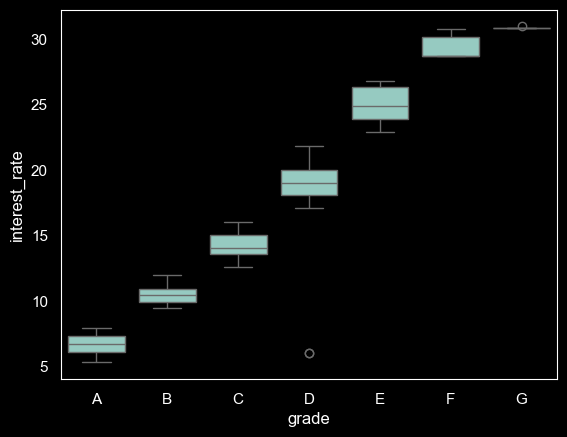

In [95]:
sns.boxplot(
    data=df,
    x='grade',
    y='interest_rate',
    order=['A','B','C','D','E','F','G'],

)

The evidence suggests that the constructed overall risk variable captures meaningful borrower risk behavior, as it shows consistent and statistically significant alignment with both loan grade and interest rate.

**This suggests that interest rate may be a stronger indicator of borrower risk behavior than income, DTI, or installment levels, which may be influenced by confounding factors or underwriting effects. Two plausible explanations emerge: either higher interest rates are assigned in response to borrowers’ underlying risky behavior (risk-based pricing), or higher interest rates themselves contribute to the emergence of risky behavior by increasing repayment burden. In either case, the alignment between rising interest rates and worsening risk behavior indicates a strong relationship between loan pricing and observed borrower risk.**

In [ ]:
#Analysing interest against income,dti,credit utilization ratio

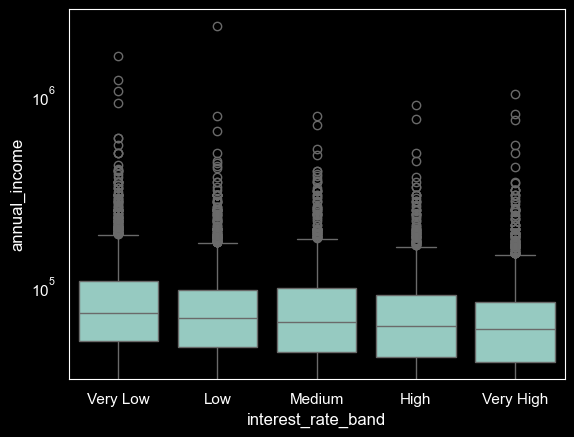

In [107]:
df['interest_rate_band'] = pd.qcut(df['interest_rate'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
sns.boxplot(data=df,x='interest_rate_band',y='annual_income')
plt.yscale('log') 

In [111]:
df['annual_income_band'] = pd.qcut(df['annual_income'], q=10)
pd.crosstab(
    df['annual_income_band'],
    df['interest_rate_band'],
    normalize='index'
)*100

interest_rate_band,Very Low,Low,Medium,High,Very High
annual_income_band,,,,,
"(-0.001, 32000.0]",14.326376,17.931689,19.449715,23.529412,24.762808
"(32000.0, 40521.6]",16.279070,20.824524,18.710359,22.515856,21.670190
"(40521.6, 50000.0]",19.170124,18.921162,17.012448,23.817427,21.078838
"(50000.0, 58000.0]",21.641791,22.139303,18.159204,18.656716,19.402985
"(58000.0, 65000.0]",20.660377,20.943396,16.981132,22.830189,18.584906
"(65000.0, 75000.0]",22.410546,22.787194,16.290019,20.150659,18.361582
"(75000.0, 87313.2]",23.820483,21.518987,18.181818,17.376295,19.102417
"(87313.2, 104000.0]",23.552502,21.884200,18.645731,20.804711,15.112856
"(104000.0, 135000.0]",25.757576,21.818182,20.000000,19.494949,12.929293


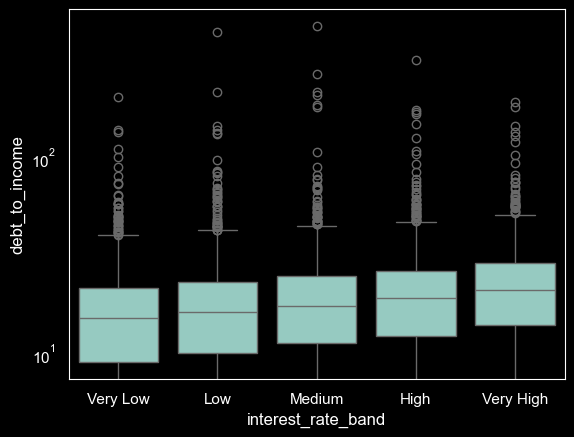

In [114]:
sns.boxplot(data=df,x='interest_rate_band',y='debt_to_income')
plt.yscale('log') 

In [115]:
df['debt_to_income_band'] = pd.qcut(df['debt_to_income'], q=10)
pd.crosstab(
    df['debt_to_income_band'],
    df['interest_rate_band'],
    normalize='index'
)*100

interest_rate_band,Very Low,Low,Medium,High,Very High
debt_to_income_band,,,,,
"(-0.001, 6.125]",31.162325,23.547094,15.931864,17.034068,12.324649
"(6.125, 9.7]",29.500000,25.500000,17.400000,16.300000,11.300000
"(9.7, 12.45]",25.450902,22.945892,19.238477,18.937876,13.426854
"(12.45, 15.08]",23.115578,22.412060,20.502513,18.492462,15.477387
"(15.08, 17.57]",24.375624,22.577423,17.982018,18.481518,16.583417
"(17.57, 20.25]",21.921922,19.919920,19.919920,21.921922,16.316316
"(20.25, 23.24]",17.971888,21.586345,16.967871,23.393574,20.080321
"(23.24, 27.03]",18.373494,19.277108,16.465863,22.791165,23.092369
"(27.03, 32.375]",14.472362,16.884422,18.291457,24.824121,25.527638


<Axes: xlabel='interest_rate_band', ylabel='credit_utilization_ratio'>

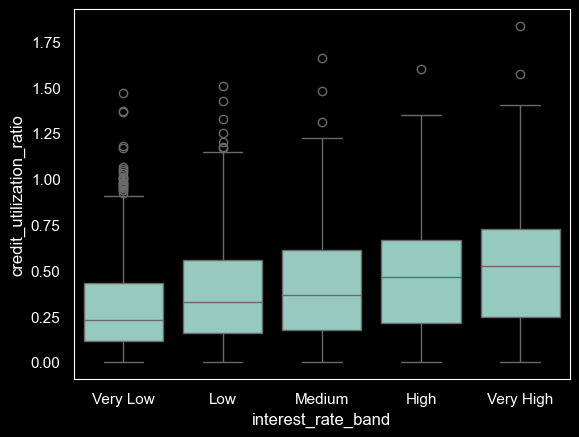

In [117]:
sns.boxplot(data=df,x='interest_rate_band',y='credit_utilization_ratio')